In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from train.train_real import run
from DNAnet.preprocessing.drc import DynamicRangeCompress
from DNAnet.preprocessing.pipeline import PreprocessingPipeline
from DNAnet.preprocessing.standardize import Standardizer

KeyboardInterrupt: 

In [ ]:
preprocessing_steps = \
    PreprocessingPipeline([
        Standardizer(per_dye=True, axis=1),
        DynamicRangeCompress(method='tanh', factor=1)
    ])

In [ ]:
run(
    data_config="synth_data.yaml",
    model_config="unet_amar.yaml",
    training_config="training_amar.yaml",
    preprocessing_steps=preprocessing_steps,
)

2025-08-19 14:35:47 INFO     Logs will be written to output/test-preprocessing/20250819_143547/log_training.txt
2025-08-19 14:35:47 INFO     Split configuration: confidence.models.Configuration(keys=['train', 'val', 'test'])
2025-08-19 14:36:02 INFO     Applying preprocessing steps: <DNAnet.preprocessing.pipeline.PreprocessingPipeline object at 0x14a18f2b0>
2025-08-19 14:36:03 INFO     Training set: 204
2025-08-19 14:36:03 INFO     Validation set: 26
2025-08-19 14:36:03 INFO     Test set: 26
2025-08-19 14:36:03 INFO     Using device: cpu
2025-08-19 14:36:03 INFO     Will start training from scratch
2025-08-19 14:36:03 INFO     Starting training...
2025-08-19 14:36:03 INFO     Setting up OneCycleLR scheduler, starting with learning rate 0.001
Epoch 1/200: 100%|██████████| 6/6 [00:08<00:00,  1.41s/it, training_loss=0.993]
2025-08-19 14:36:11 INFO     Epoch 1/200 - Training binaryaccuracy: 0.721943
2025-08-19 14:36:11 INFO     Epoch 1/200 - Training loss: 0.993168
Epoch 1/200: 1it [00:00,

In [ ]:
from config_io import load_model

unet_model = load_model("config/models/unet_amar_1.yaml")
unet_model.load("output/real_data-best_unet-use_scheduler-delta_1/checkpoint/")

FileNotFoundError: [Errno 2] No such file or directory: 'config/models/config/models/unet_amar_1.yaml'

In [ ]:
from DNAnet.data.data_models import Panel
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer
from DNAnet.data.parsing.file_parsing import find_files_by_suffix
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard


from typing import List
from pathlib import Path

gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
reference_genotype_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/ProvedIt/References"

panel = Panel(gf_panel_path)
hid_files = find_files_by_suffix(hid_files_path, ".hid")
file_categorizer = ProvedItFileCategorizer()
sample_validator = NFIValidationStrategy()

images = CustomHIDDataset(
    root_path=hid_files_path,
    panel_path=gf_panel_path,
    size_standard=InternalSizeStandard.GENESCAN_600_LIZ.value,
    file_categorization_strategy=file_categorizer,
    sample_validation_strategy=sample_validator,
)

2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation on

In [ ]:
predictions = unet_model.predict_batch(images)

2025-06-27 17:26:23 INFO     Calling alleles from predicted segmentation...
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:26:23 WARNING  No predictions present in dye row 4
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:26:23 WARNING  No predictions present in dye row 4
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:

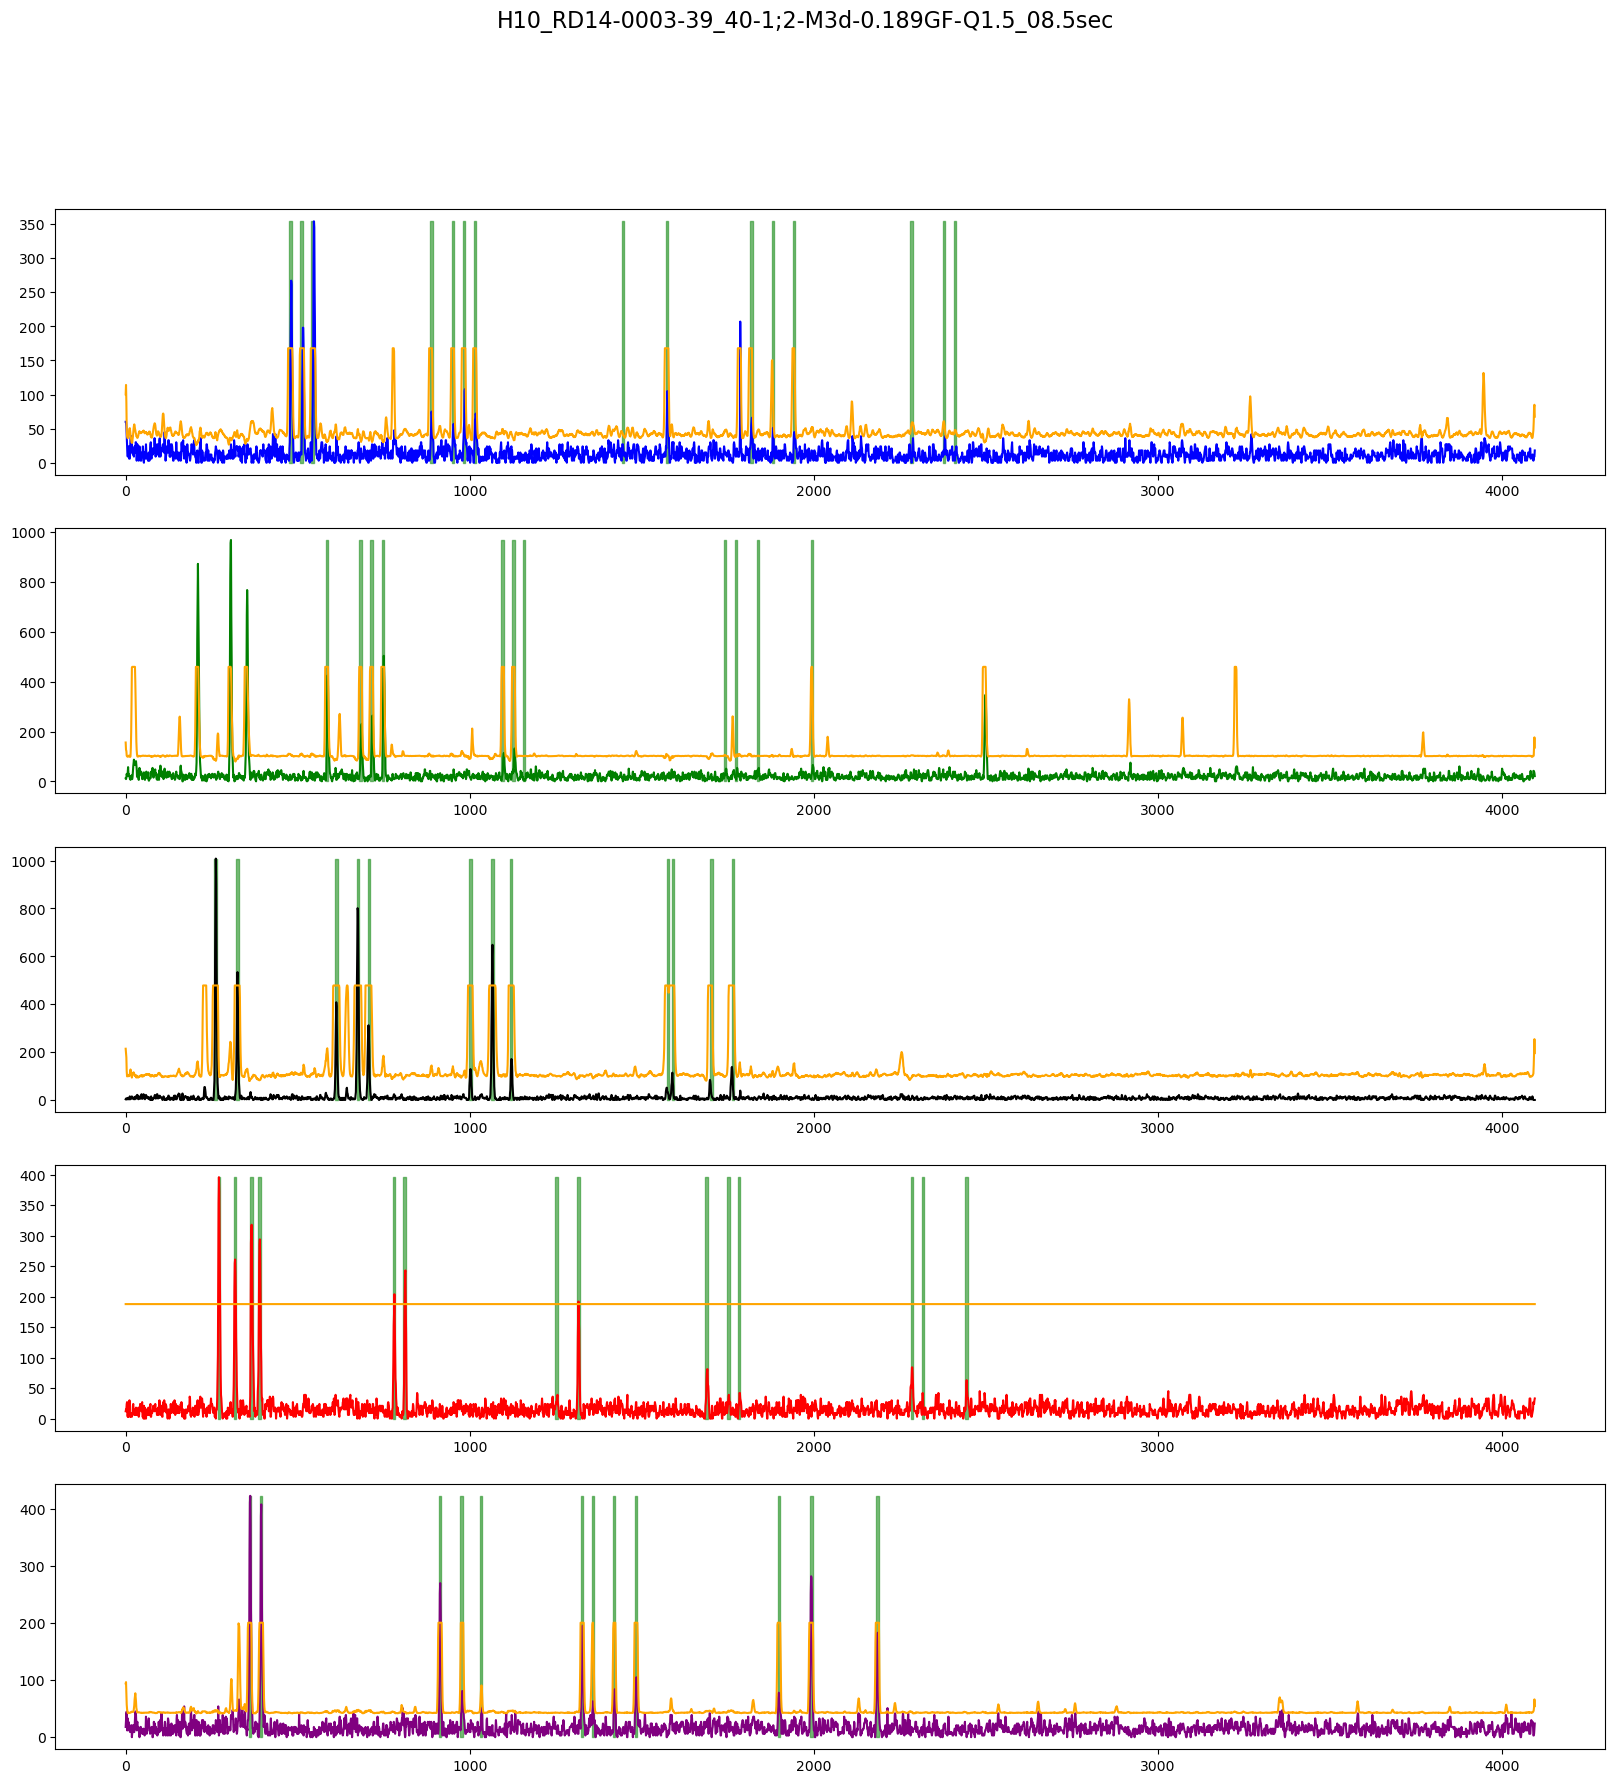

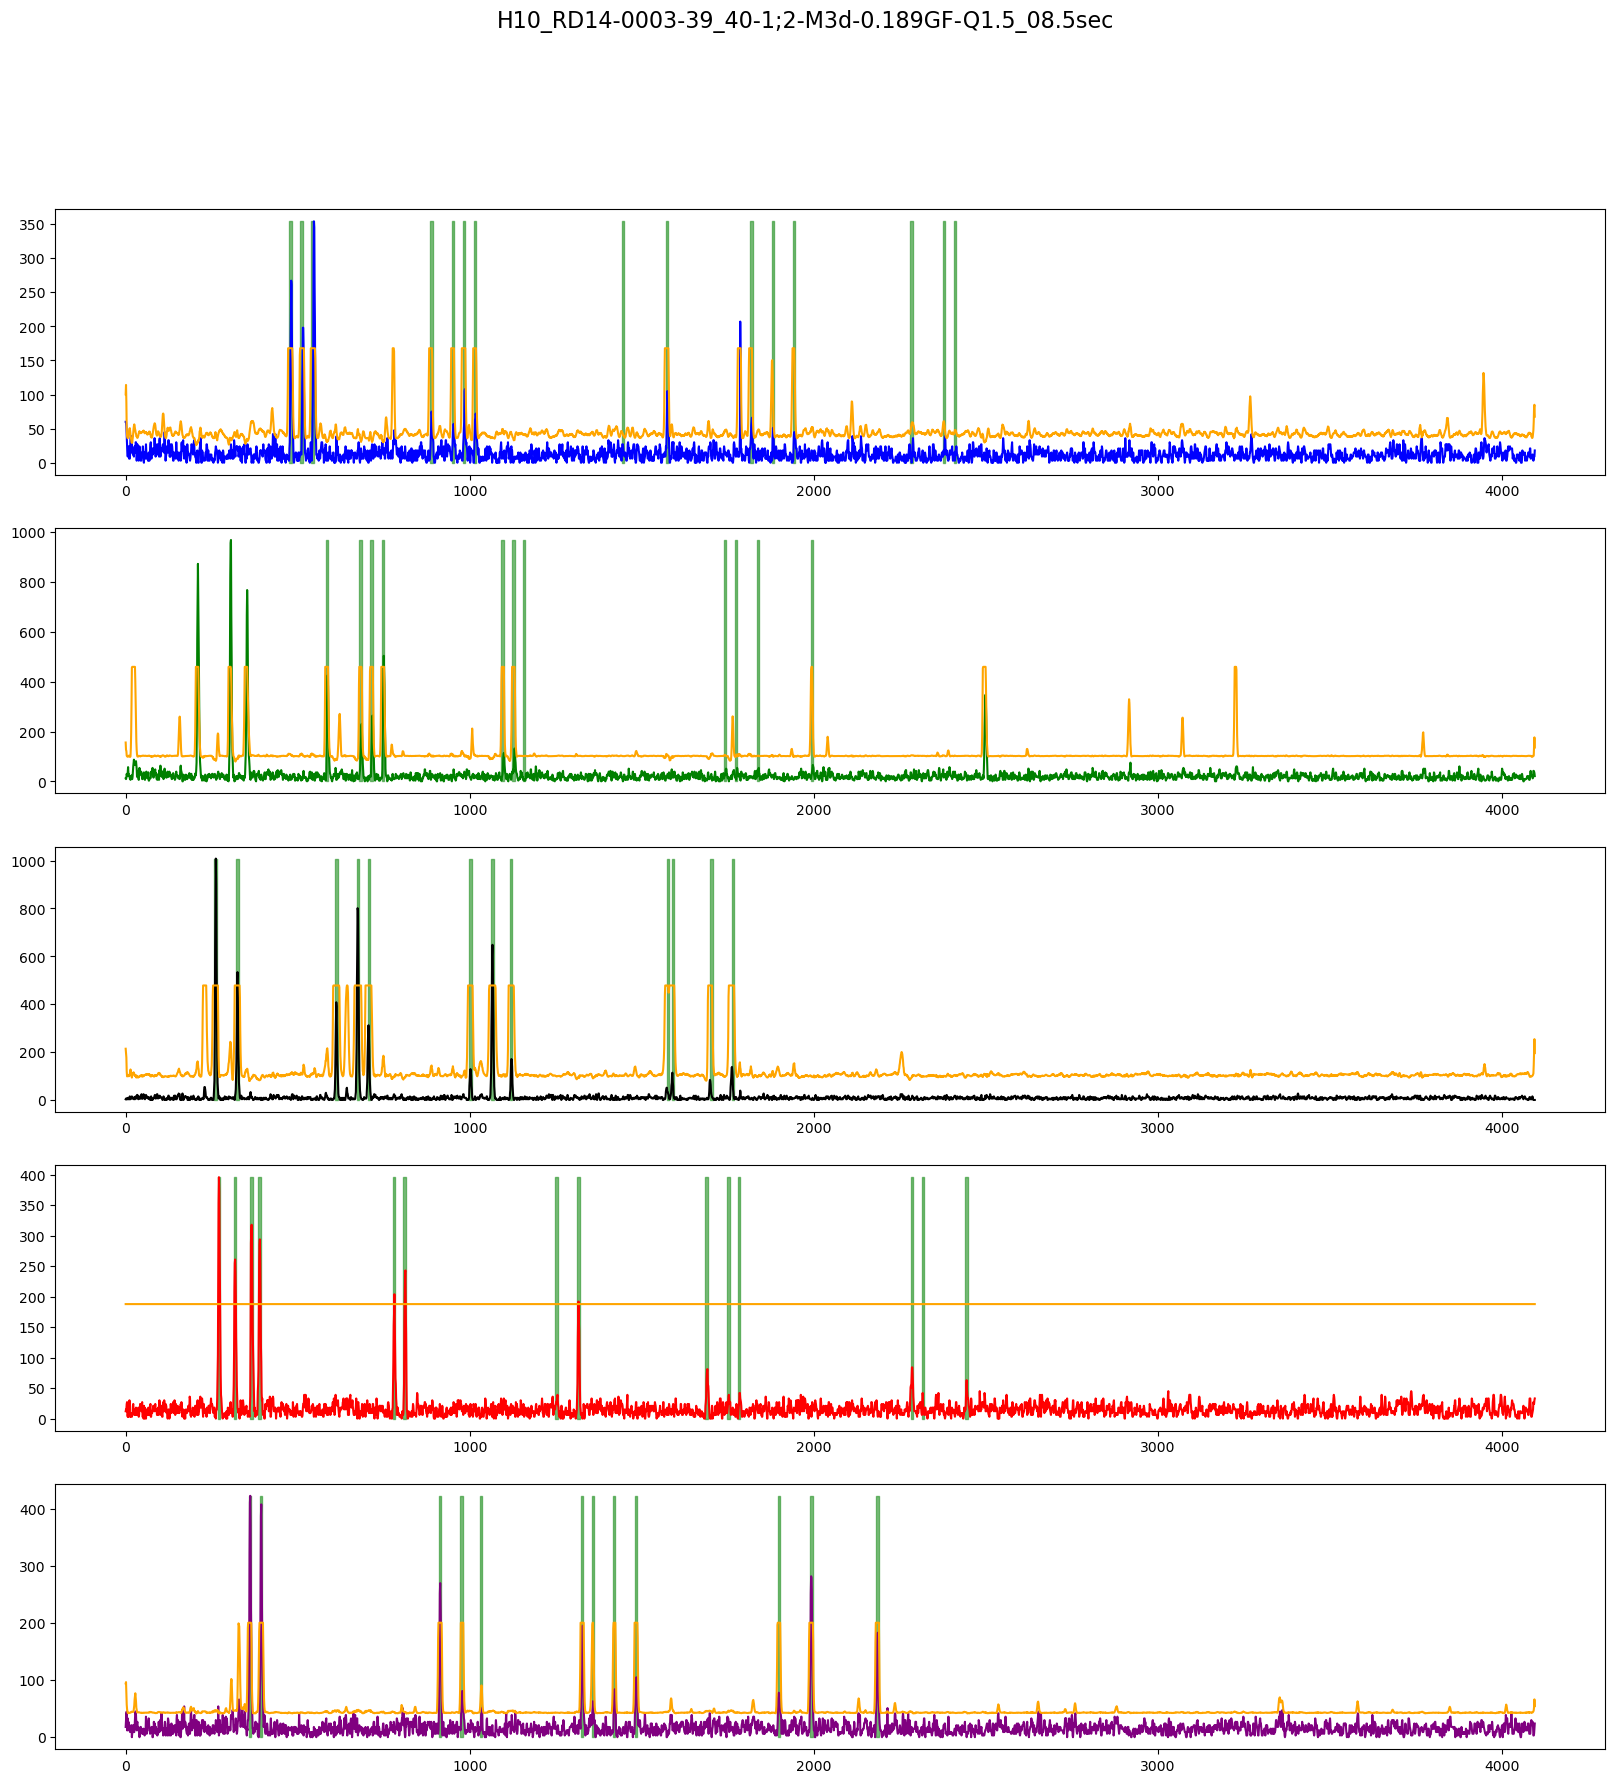

In [ ]:
from DNAnet.evaluation.visualizations import plot_profile


plot_profile(images[:1], predictions[:1], prediction_as_mask=False)

In [ ]:
best_unet_model = load_model("config/models/unet.yaml")
best_unet_model.load("resources/model/current_best_unet/")

In [ ]:
best_predictions = best_unet_model.predict_batch(images[:1])

2025-06-27 17:26:35 INFO     Calling alleles from predicted segmentation...


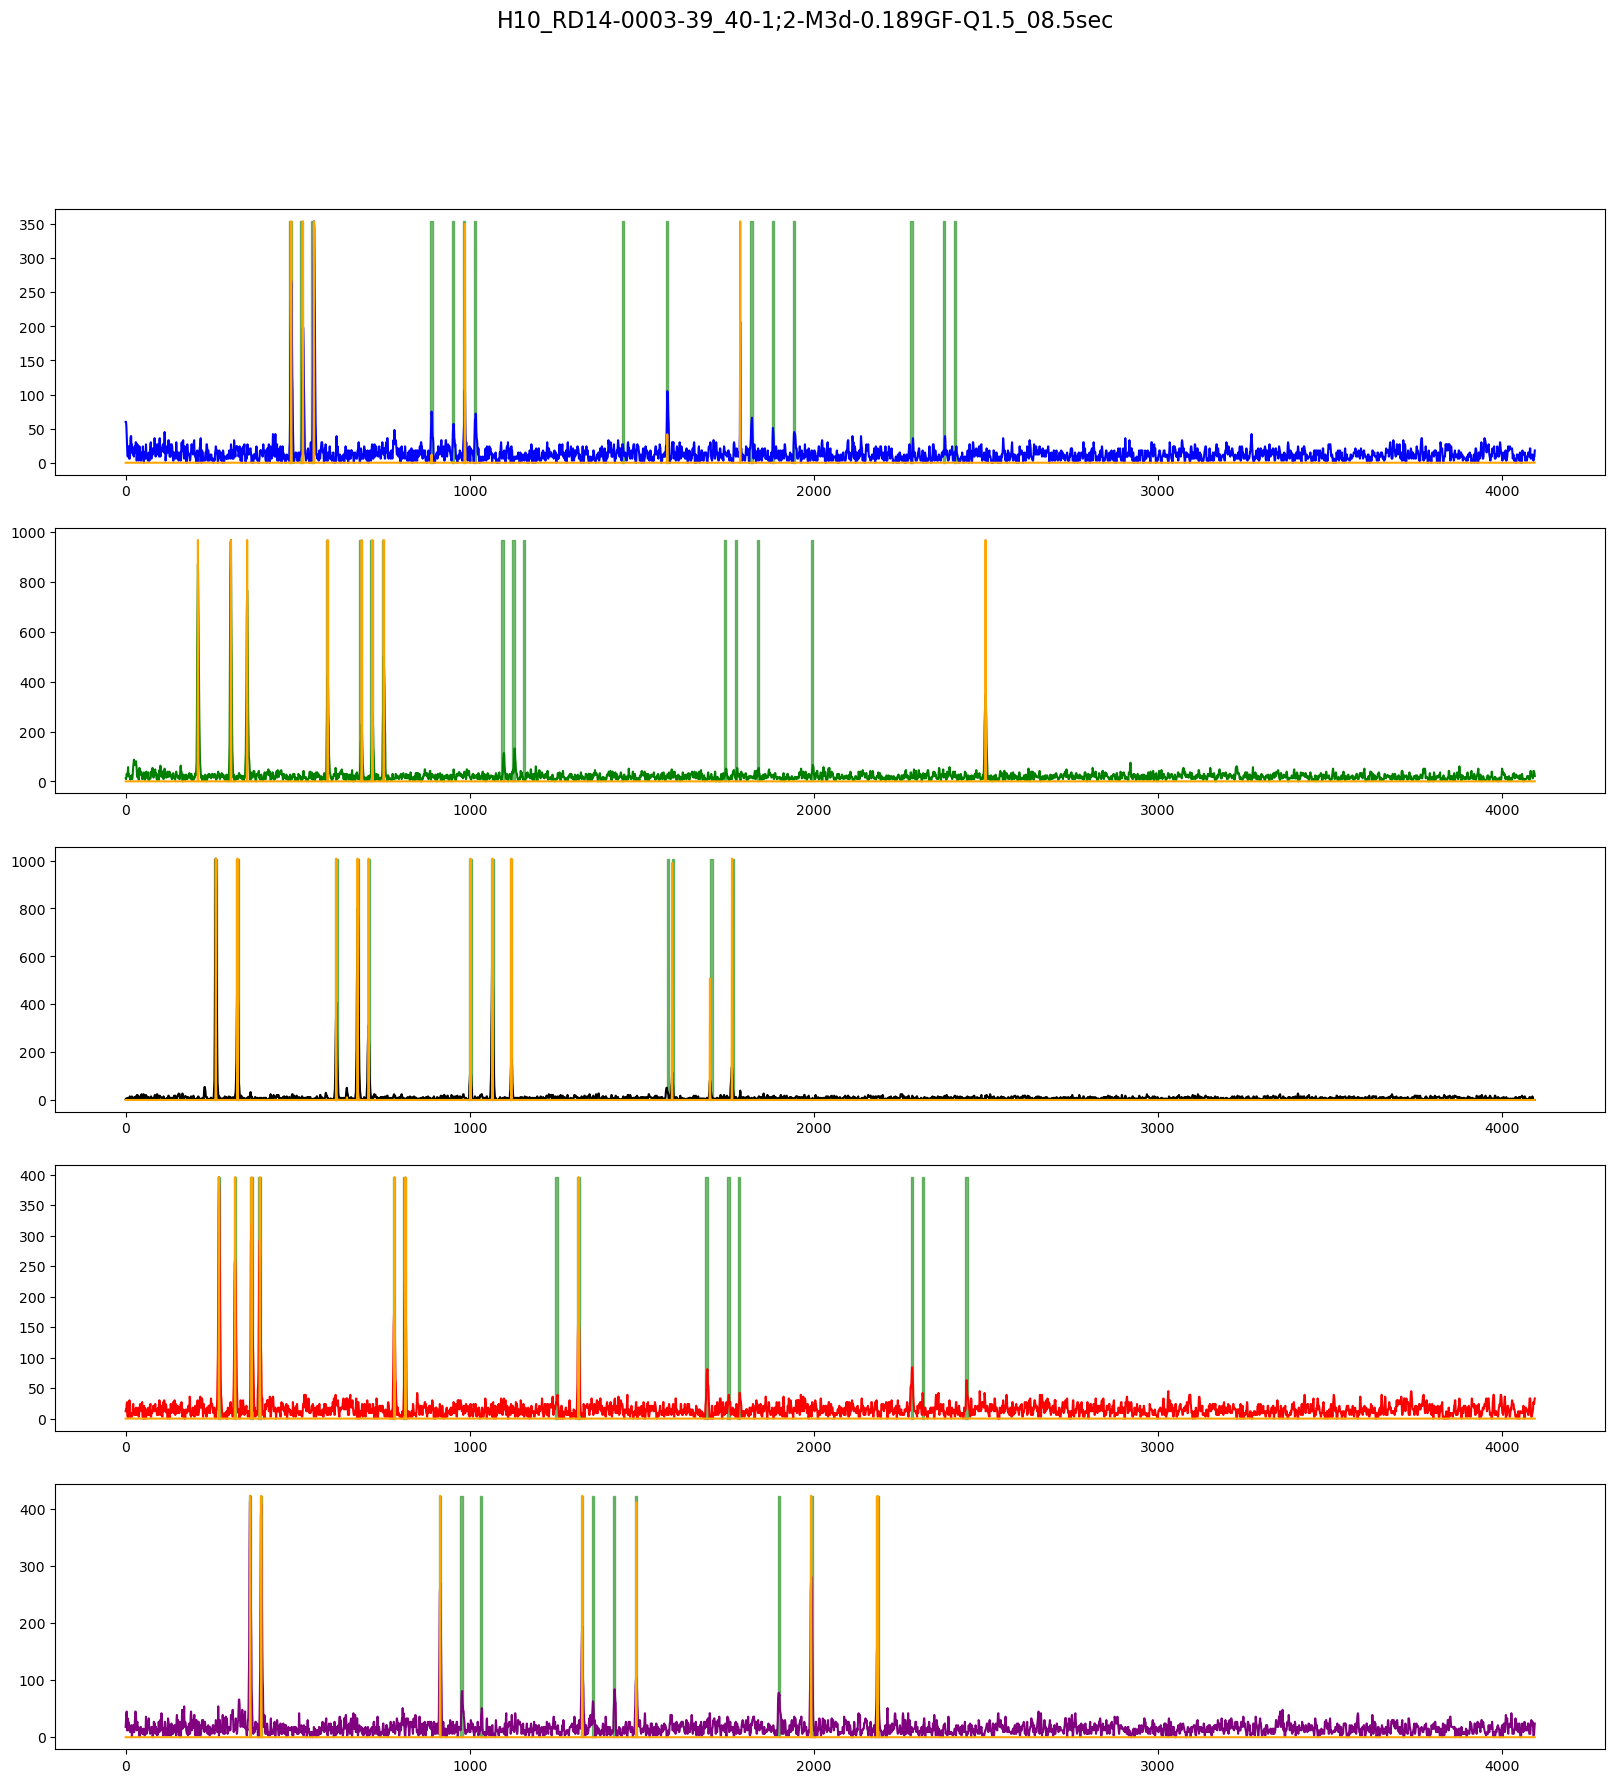

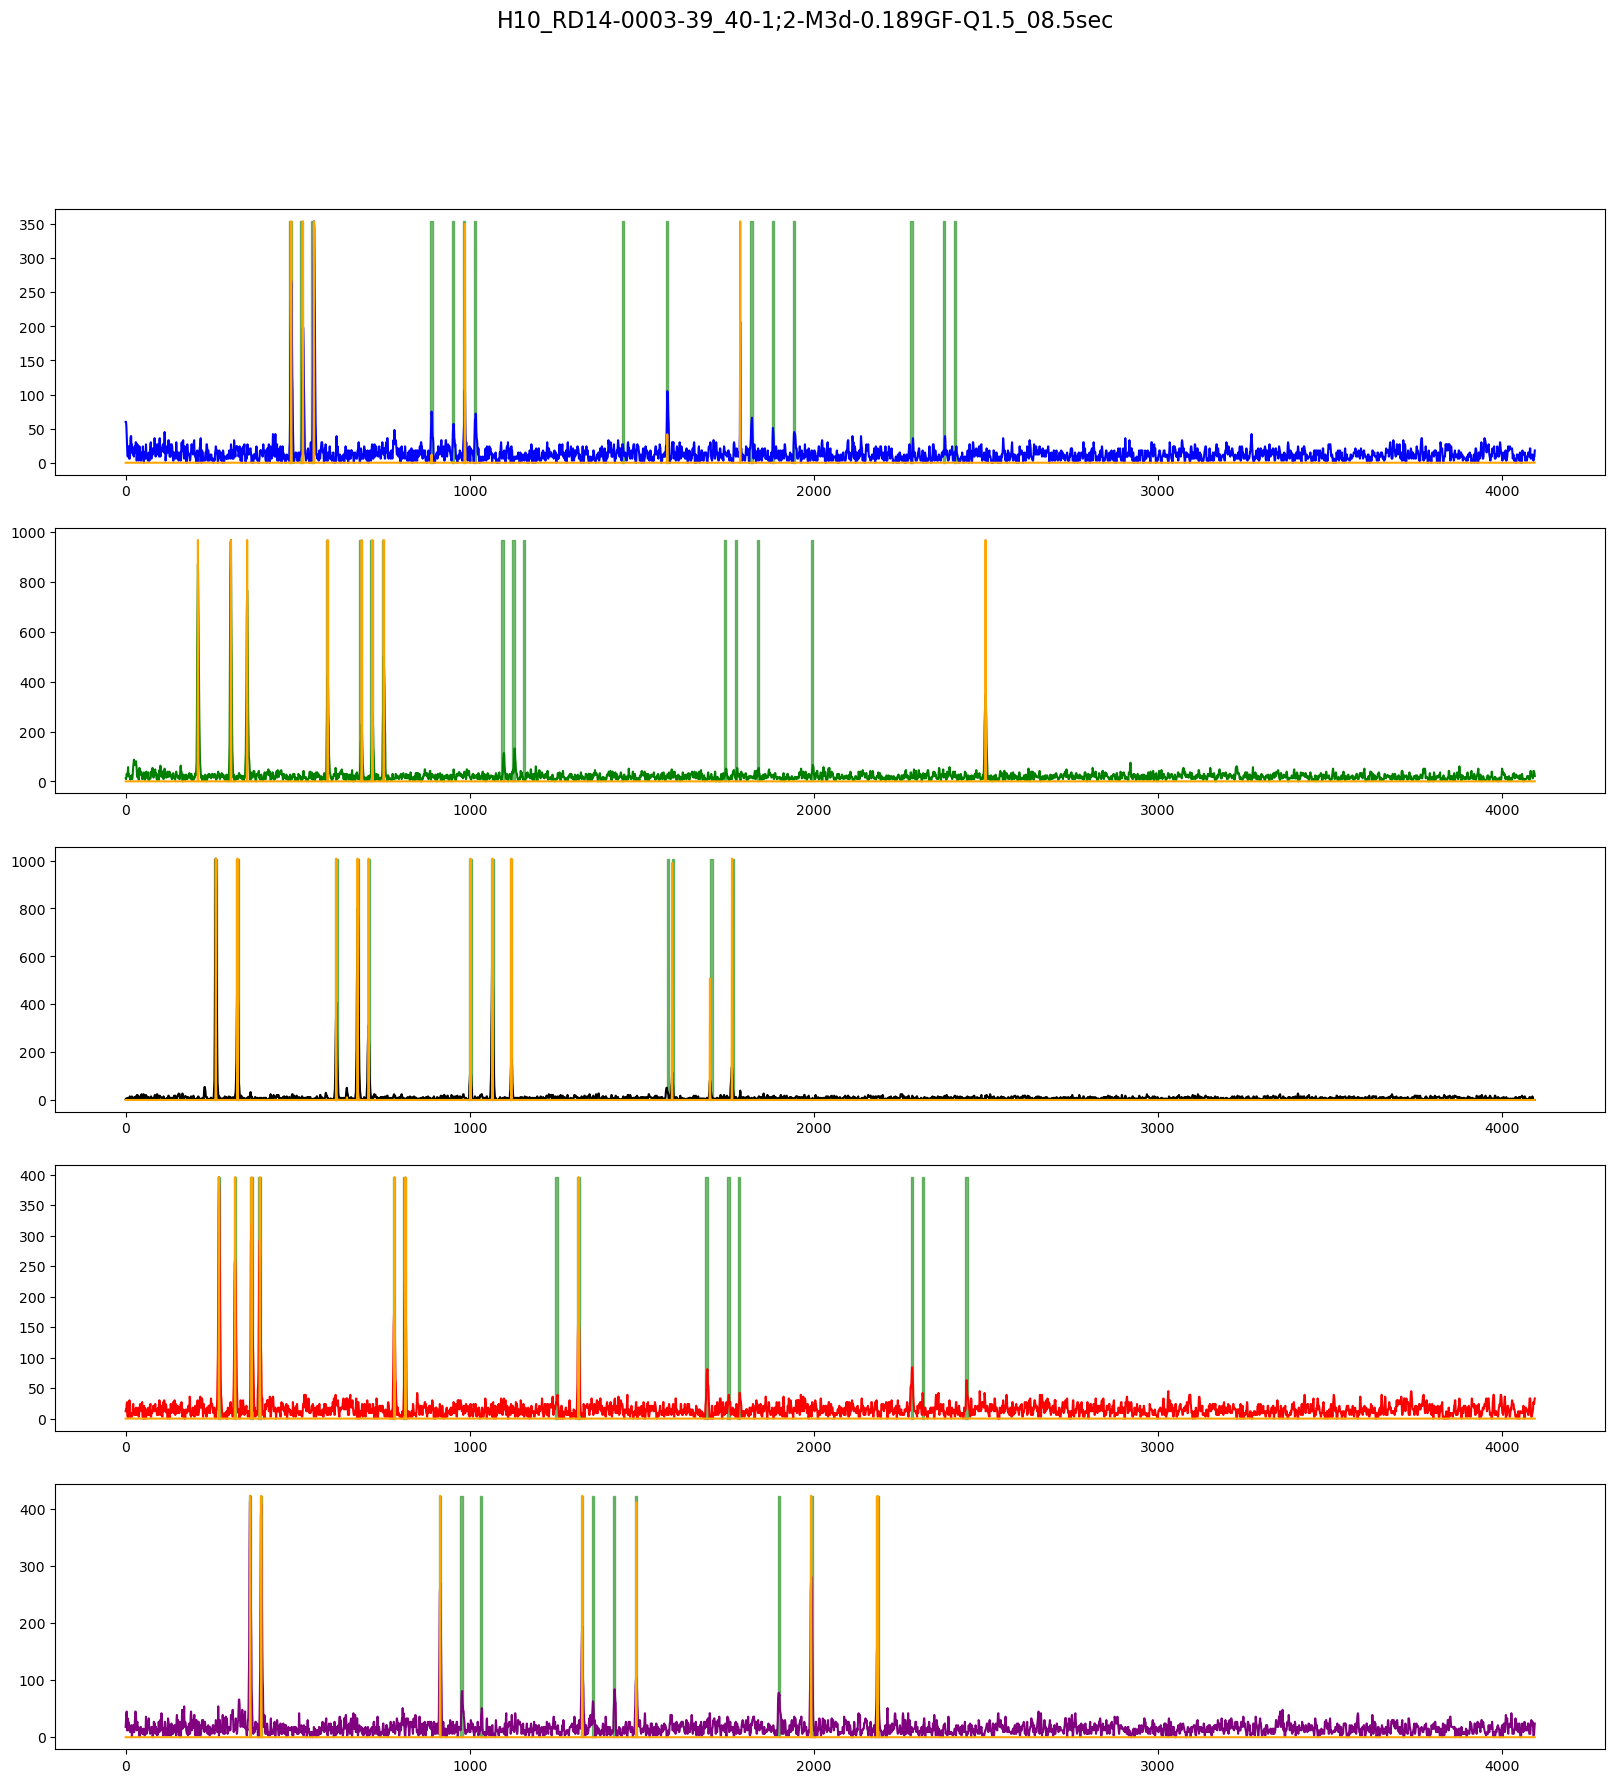

In [ ]:
plot_profile(images[:1], best_predictions[:1], prediction_as_mask=False)